<a href="https://colab.research.google.com/github/alessandra-cardozo/ALURAMIDI-ALESSANDRACARDOZO/blob/main/Imers%C3%A3o_Alessandra_Agentes_de_IA_Alura%2BGoogle_Gemini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [87]:
!pip install -q --upgrade langchain langchain-google-genai google-generativeai==0.8.5

In [88]:
from google.colab import userdata
from langchain_google_genai import ChatGoogleGenerativeAI

GOOGLE_API_KEY = userdata.get('GEMINI_API_KEY')

In [89]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
    api_key=GOOGLE_API_KEY
)

In [90]:
resp_test = llm.invoke("O que é inteligência artificial?")


In [91]:
print(resp_test)

content='Inteligência Artificial (IA) é um **campo da ciência da computação que se dedica a criar sistemas ou máquinas capazes de simular a inteligência humana**. O objetivo principal é permitir que essas máquinas realizem tarefas que normalmente exigiriam cognição humana, como aprender, raciocinar, resolver problemas, perceber, compreender a linguagem e tomar decisões.\n\nEm termos mais simples, a IA busca fazer com que computadores e softwares pensem e ajam de forma "inteligente".\n\n**Principais Capacidades e Características da IA:**\n\n1.  **Aprendizado (Machine Learning - ML):** A capacidade de aprender com dados e experiências, sem ser explicitamente programada para cada cenário. Em vez de seguir instruções fixas, a IA pode identificar padrões, fazer previsões e melhorar seu desempenho ao longo do tempo.\n    *   **Deep Learning (DL):** Um subcampo do Machine Learning que utiliza redes neurais artificiais com múltiplas camadas (inspiradas no cérebro humano) para aprender represen

In [92]:
TRIAGEM_PROMPT = (
    "Você é um triador de Service Desk para políticas internas da empresa Alessandra Desenvolvimento. "
    "Dada a mensagem do usuário, retorne SOMENTE um JSON com:\n"
    "{\n"
    '  "decisao": "AUTO_RESOLVER" | "PEDIR_INFO" | "ABRIR_CHAMADO",\n'
    '  "urgencia": "BAIXA" | "MEDIA" | "ALTA",\n'
    '  "campos_faltantes": ["..."]\n'
    "}\n"
    "Regras:\n"
    '- **AUTO_RESOLVER**: Perguntas claras sobre regras ou procedimentos descritos nas políticas (Ex: "Posso reembolsar a internet do meu home office?", "Como funciona a política de alimentação em viagens?").\n'
    '- **PEDIR_INFO**: Mensagens vagas ou que faltam informações para identificar o tema ou contexto (Ex: "Preciso de ajuda com uma política", "Tenho uma dúvida geral").\n'
    '- **ABRIR_CHAMADO**: Pedidos de exceção, liberação, aprovação ou acesso especial, ou quando o usuário explicitamente pede para abrir um chamado (Ex: "Quero exceção para trabalhar 5 dias remoto.", "Solicito liberação para anexos externos.", "Por favor, abra um chamado para o RH.").'
    "Analise a mensagem e decida a ação mais apropriada."
)

In [93]:
from pydantic import BaseModel, Field
from typing import Literal, List, Dict

class TriagemOut(BaseModel):
    decisao: Literal["AUTO_RESOLVER", "PEDIR_INFO", "ABRIR_CHAMADO"]
    urgencia: Literal["BAIXA", "MEDIA", "ALTA"]
    campos_faltantes: List[str] = Field(default_factory=list)

In [94]:
llm_triagem = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.0,
    api_key=GOOGLE_API_KEY
)

In [95]:
from langchain_core.messages import SystemMessage, HumanMessage

triagem_chain = llm_triagem.with_structured_output(TriagemOut)

def triagem(mensagem: str) -> Dict:
    saida: TriagemOut = triagem_chain.invoke([
        SystemMessage(content=TRIAGEM_PROMPT),
        HumanMessage(content=mensagem)
    ])

    return saida.model_dump()

In [96]:
testes = ["Posso reembolsar a internet?",
          "Quero mais 5 dias de trabalho remoto. Como faço?",
          "Posso reembolsar cursos ou treinamentos da Alura?",
          "Quantas capivaras tem no Rio Pinheiros?"]

In [97]:
for msg_teste in testes:
    print(f"Pergunta: {msg_teste}\n -> Resposta: {triagem(msg_teste)}\n")


Pergunta: Posso reembolsar a internet?
 -> Resposta: {'decisao': 'AUTO_RESOLVER', 'urgencia': 'BAIXA', 'campos_faltantes': []}

Pergunta: Quero mais 5 dias de trabalho remoto. Como faço?
 -> Resposta: {'decisao': 'ABRIR_CHAMADO', 'urgencia': 'MEDIA', 'campos_faltantes': []}

Pergunta: Posso reembolsar cursos ou treinamentos da Alura?
 -> Resposta: {'decisao': 'AUTO_RESOLVER', 'urgencia': 'BAIXA', 'campos_faltantes': []}

Pergunta: Quantas capivaras tem no Rio Pinheiros?
 -> Resposta: {'decisao': 'PEDIR_INFO', 'urgencia': 'BAIXA', 'campos_faltantes': ['informacao_relevante_a_politica']}



AULA 02

In [98]:
!pip install -q --upgrade langchain_community faiss-cpu langchain-text-splitters pymupdf

In [99]:
from pathlib import Path
from langchain_community.document_loaders import PyMuPDFLoader

docs = []
# Altere o caminho do arquivo para o seu arquivo PDF
file_path = "/content/TOMOGRAFIA ABDOME E PELVE.pdf" # Caminho para o arquivo PDF do usuário

try:
    loader = PyMuPDFLoader(file_path)
    docs.extend(loader.load())
    print(f"Carregado com sucesso arquivo {Path(file_path).name}")
except Exception as e:
    print(f"Erro ao carregar arquivo {Path(file_path).name}: {e}")

print(f"Total de documentos carregados: {len(docs)}")

Carregado com sucesso arquivo TOMOGRAFIA ABDOME E PELVE.pdf
Total de documentos carregados: 2


In [100]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=30)

chunks = splitter.split_documents(docs)

In [101]:
for chunk in chunks:
    print(chunk)
    print("------------------------------------")

page_content='CENTRO DE PREVENÇÃO E DIAGNÓSTICO
Pedido: 218383
Data Nascimento: 15/07/1975
Nome: ALESSANDRA CARDOZO DOS
SANTOS
Idade: 49
Médico: LYEGE DE OLIVEIRA
N38941Registro: 23815001
Data Emissão:11/02/2025 09:00:23
Data do Exame:09/09/2024 08:29:00
JOSE INACIO TITO JORGE FILHO
CRM: 215644' metadata={'producer': 'iTextSharp™ 5.5.3 ©2000-2014 iText Group NV (AGPL-version)', 'creator': '', 'creationdate': '2025-08-26T12:16:48-03:00', 'source': '/content/TOMOGRAFIA ABDOME E PELVE.pdf', 'file_path': '/content/TOMOGRAFIA ABDOME E PELVE.pdf', 'total_pages': 2, 'format': 'PDF 1.4', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2025-08-26T12:16:48-03:00', 'trapped': '', 'modDate': "D:20250826121648-03'00'", 'creationDate': "D:20250826121648-03'00'", 'page': 0}
------------------------------------
page_content='CRM: 215644
Av. Celso Garcia, 2294 - Belém - São Paulo - SP - CEP:03014-000 - Tel: (11) 2799-3100 / www.hsv.org.br
TOMOGRAFIA COMPUTADORIZADA DO ABDOME E PEL

In [102]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings

embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001",
    google_api_key=GOOGLE_API_KEY
)

In [103]:
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(chunks, embeddings)

retriever = vectorstore.as_retriever(search_type="similarity_score_threshold",
                                     search_kwargs={"score_threshold":0.3, "k": 4})

In [104]:
from langchain_core.prompts import ChatPromptTemplate
from langchain.chains.combine_documents import create_stuff_documents_chain

prompt_rag = ChatPromptTemplate.from_messages([
    ("system",
     "Você é um Assistente que responde perguntas com base em um relatório médico fornecido. "
     "Responda SOMENTE com base no contexto do relatório. "
     "Se a informação não estiver no relatório, responda apenas 'Não sei'."),

    ("human", "Pergunta: {input}\n\nContexto:\n{context}")
])

document_chain = create_stuff_documents_chain(llm_triagem, prompt_rag)

In [105]:
# Formatadores
import re, pathlib

def _clean_text(s: str) -> str:
    return re.sub(r"\s+", " ", s or "").strip()

def extrair_trecho(texto: str, query: str, janela: int = 240) -> str:
    txt = _clean_text(texto)
    termos = [t.lower() for t in re.findall(r"\w+", query or "") if len(t) >= 4]
    pos = -1
    for t in termos:
        pos = txt.lower().find(t)
        if pos != -1: break
    if pos == -1: pos = 0
    ini, fim = max(0, pos - janela//2), min(len(txt), pos + janela//2)
    return txt[ini:fim]

def formatar_citacoes(docs_rel: List, query: str) -> List[Dict]:
    cites, seen = [], set()
    for d in docs_rel:
        src = pathlib.Path(d.metadata.get("source","")).name
        page = int(d.metadata.get("page", 0)) + 1
        key = (src, page)
        if key in seen:
            continue
        seen.add(key)
        cites.append({"documento": src, "pagina": page, "trecho": extrair_trecho(d.page_content, query)})
    return cites[:3]

In [106]:
def perguntar_politica_RAG(pergunta: str) -> Dict:
    docs_relacionados = retriever.invoke(pergunta)

    if not docs_relacionados:
        return {"answer": "Não sei.",
                "citacoes": [],
                "contexto_encontrado": False}

    answer = document_chain.invoke({"input": pergunta,
                                    "context": docs_relacionados})

    txt = (answer or "").strip()

    if txt.rstrip(".!?") == "Não sei":
        return {"answer": "Não sei.",
                "citacoes": [],
                "contexto_encontrado": False}

    return {"answer": txt,
            "citacoes": formatar_citacoes(docs_relacionados, pergunta),
            "contexto_encontrado": True}

In [107]:
testes = ["Qual o nome do paciente?",
          "Qual a data do exame?",
          "Há alguma alteração no fígado?",
          "O que foi encontrado na parede abdominal?",
          "Quantos anos tem o paciente?",
          "Existe alguma recomendação no relatório?"]

In [108]:
for msg_teste in testes:
    resposta = perguntar_politica_RAG(msg_teste)
    print(f"PERGUNTA: {msg_teste}")
    print(f"RESPOSTA: {resposta['answer']}")
    if resposta['contexto_encontrado']:
        print("CITAÇÕES:")
        for c in resposta['citacoes']:
            print(f" - Documento: {c['documento']}, Página: {c['pagina']}")
            print(f"   Trecho: {c['trecho']}")
        print("------------------------------------")

PERGUNTA: Qual o nome do paciente?
RESPOSTA: O nome do paciente é ALESSANDRA CARDOZO DOS SANTOS.
CITAÇÕES:
 - Documento: TOMOGRAFIA ABDOME E PELVE.pdf, Página: 1
   Trecho: CENTRO DE PREVENÇÃO E DIAGNÓSTICO Pedido: 218383 Data Nascimento: 15/07/1975 Nome: ALESSANDRA CARDOZO DOS SANTOS Idade: 49 Médico: LYEGE DE OLIVEIRA N38941Registro: 23815001 Data Emissão:11/02/2025
 - Documento: TOMOGRAFIA ABDOME E PELVE.pdf, Página: 2
   Trecho: CENTRO DE PREVENÇÃO E DIAGNÓSTICO Pedido: 218383 Data Nascimento: 15/07/1975 Nome: ALESSANDRA CARDOZO DOS SANTOS Idade: 49 Médico: LYEGE DE OLIVEIRA N38941Registro: 23815001 Data Emissão:11/02/2025
------------------------------------
PERGUNTA: Qual a data do exame?
RESPOSTA: 09/09/2024
CITAÇÕES:
 - Documento: TOMOGRAFIA ABDOME E PELVE.pdf, Página: 1
   Trecho: CENTRO DE PREVENÇÃO E DIAGNÓSTICO Pedido: 218383 Data Nascimento: 15/07/1975 Nome: ALESSANDRA CARDOZO DOS SANTOS Idade: 49 Médico: LYEGE DE OLIVEIRA N38941Registro: 2381
 - Documento: TOMOGRAFIA ABDO

In [109]:
# Escolha uma pergunta de teste para ilustrar
pergunta_exemplo = testes[2] # Por exemplo, a terceira pergunta: "Há alguma alteração no fígado?"

print(f"Pergunta de Exemplo: {pergunta_exemplo}\n")

# Passo 1: Recuperar os documentos relevantes (chunks)
print("Passo 1: Recuperando documentos relevantes...")
docs_relevantes = retriever.invoke(pergunta_exemplo)

if docs_relevantes:
    print(f"Encontrados {len(docs_relevantes)} documentos relevantes (chunks):\n")
    for i, doc in enumerate(docs_relevantes):
        print(f"--- Chunk {i+1} (Página: {doc.metadata.get('page', 0)+1}, Documento: {Path(doc.metadata.get('source', '')).name}) ---")
        print(doc.page_content)
        print("-" * (len(f"--- Chunk {i+1} (Página: {doc.metadata.get('page', 0)+1}, Documento: {Path(doc.metadata.get('source', '')).name}) ---")))
    print("\n" + "="*50 + "\n")

    # Passo 2: Gerar a resposta usando os documentos recuperados e o modelo
    print("Passo 2: Gerando a resposta com base nos documentos recuperados e no modelo...")
    resposta_completa = perguntar_politica_RAG(pergunta_exemplo) # Reutiliza a função que já orquestra a cadeia e formatação

    print("\n" + "="*50 + "\n")
    print("Resposta Final Gerada:")
    print(resposta_completa['answer'])

    if resposta_completa['citacoes']:
        print("\nCitações (Referências encontradas no relatório):")
        for cite in resposta_completa['citacoes']:
            print(f" - Documento: {cite['documento']}, Página: {cite['pagina']}")
            print(f"   Trecho: {cite['trecho']}")
else:
    print("Nenhum documento relevante encontrado para esta pergunta.")
    print("\n" + "="*50 + "\n")
    resposta_completa = perguntar_politica_RAG(pergunta_exemplo)
    print("Resposta Final Gerada:")
    print(resposta_completa['answer'])

Pergunta de Exemplo: Há alguma alteração no fígado?

Passo 1: Recuperando documentos relevantes...
Encontrados 4 documentos relevantes (chunks):

--- Chunk 1 (Página: 1, Documento: TOMOGRAFIA ABDOME E PELVE.pdf) ---
Análise:
Hérnia da parede abdominal em hipogástrio direito no reto abdominal, com orifício
medindo 8 mm, e extensão de 70 mm, contendo gordura no interior.
Fígado com dimensões e contornos normais, com redução difusa da densidade por
esteatose leve.
Não há dilatação das vias biliares.
---------------------------------------------------------------------
--- Chunk 2 (Página: 2, Documento: TOMOGRAFIA ABDOME E PELVE.pdf) ---
CRM: 215644
Av. Celso Garcia, 2294 - Belém - São Paulo - SP - CEP:03014-000 - Tel: (11) 2799-3100 / www.hsv.org.br
 
Impressão radiológica:
Sinais de esteatose hepática leve.
Diverticulose cólica sem sinais inflamatórios atuais.
Hérnia da parede abdominal em hipogástrio direito no reto abdominal.
------------------------------------------------------------

### Ilustração do Processo RAG (Retrieval Augmented Generation)

A célula de código abaixo demonstra o fluxo do seu sistema de perguntas e respostas, mostrando:
1.  A pergunta de exemplo utilizada.
2.  Quais "pedacinhos" (chunks) do documento PDF o sistema encontrou como relevantes.
3.  A resposta final gerada pelo modelo com base nesses pedacinhos e na pergunta.
4.  As referências (citações) de onde a informação foi retirada no documento.

Pense no processo RAG como este fluxo simplificado:

In [110]:
# Escolha uma pergunta de teste para ilustrar
pergunta_exemplo = testes[2] # Por exemplo, a terceira pergunta: "Há alguma alteração no fígado?"

print(f"Pergunta de Exemplo: {pergunta_exemplo}\n")

# Passo 1: Recuperar os documentos relevantes (chunks)
print("Passo 1: Recuperando documentos relevantes...")
docs_relevantes = retriever.invoke(pergunta_exemplo)

if docs_relevantes:
    print(f"Encontrados {len(docs_relevantes)} documentos relevantes (chunks):\n")
    for i, doc in enumerate(docs_relevantes):
        print(f"--- Chunk {i+1} (Página: {doc.metadata.get('page', 0)+1}, Documento: {Path(doc.metadata.get('source', '')).name}) ---")
        print(doc.page_content)
        print("-" * (len(f"--- Chunk {i+1} (Página: {doc.metadata.get('page', 0)+1}, Documento: {Path(doc.metadata.get('source', '')).name}) ---")))
    print("\n" + "="*50 + "\n")

    # Passo 2: Gerar a resposta usando os documentos recuperados e o modelo
    print("Passo 2: Gerando a resposta com base nos documentos recuperados e no modelo...")
    resposta_completa = perguntar_politica_RAG(pergunta_exemplo) # Reutiliza a função que já orquestra a cadeia e formatação

    print("\n" + "="*50 + "\n")
    print("Resposta Final Gerada:")
    print(resposta_completa['answer'])

    if resposta_completa['citacoes']:
        print("\nCitações (Referências encontradas no relatório):")
        for cite in resposta_completa['citacoes']:
            print(f" - Documento: {cite['documento']}, Página: {cite['pagina']}")
            print(f"   Trecho: {cite['trecho']}")
else:
    print("Nenhum documento relevante encontrado para esta pergunta.")
    print("\n" + "="*50 + "\n")
    resposta_completa = perguntar_politica_RAG(pergunta_exemplo)
    print("Resposta Final Gerada:")
    print(resposta_completa['answer'])

Pergunta de Exemplo: Há alguma alteração no fígado?

Passo 1: Recuperando documentos relevantes...
Encontrados 4 documentos relevantes (chunks):

--- Chunk 1 (Página: 1, Documento: TOMOGRAFIA ABDOME E PELVE.pdf) ---
Análise:
Hérnia da parede abdominal em hipogástrio direito no reto abdominal, com orifício
medindo 8 mm, e extensão de 70 mm, contendo gordura no interior.
Fígado com dimensões e contornos normais, com redução difusa da densidade por
esteatose leve.
Não há dilatação das vias biliares.
---------------------------------------------------------------------
--- Chunk 2 (Página: 2, Documento: TOMOGRAFIA ABDOME E PELVE.pdf) ---
CRM: 215644
Av. Celso Garcia, 2294 - Belém - São Paulo - SP - CEP:03014-000 - Tel: (11) 2799-3100 / www.hsv.org.br
 
Impressão radiológica:
Sinais de esteatose hepática leve.
Diverticulose cólica sem sinais inflamatórios atuais.
Hérnia da parede abdominal em hipogástrio direito no reto abdominal.
------------------------------------------------------------

AULA 03

In [111]:
!pip install -q --upgrade langgraph

In [112]:
from typing import TypedDict, Optional

class AgentState(TypedDict, total = False):
    pergunta: str
    triagem: dict
    resposta: Optional[str]
    citacoes: List[dict]
    rag_sucesso: bool
    acao_final: str

In [136]:
def triagem(pergunta: str) -> dict:
    termos_clinicos = [
        "tomografia", "laudo", "exame", "fígado", "abdome", "paciente",
        "recomendação médica", "idade", "parede abdominal", "hérnia", "esteatose", "diverticulose"
    ]

    if any(termo in pergunta.lower() for termo in termos_clinicos):
        return {
            "decisao": "AUTO_RESOLVER",
            "urgencia": "BAIXA",
            "acao_final": "AUTO_RESOLVER"
        }

    # Se não reconhecer como clínico, segue o fluxo padrão
    return {
        "decisao": "PEDIR_INFO",
        "urgencia": "BAIXA",
        "acao_final": "PEDIR_INFO"
    }


In [137]:
def node_auto_resolver(state: AgentState) -> AgentState:
    print("Executando nó de auto_resolver...")
    resposta_rag = perguntar_politica_RAG(state["pergunta"])

    update: AgentState = {
        "resposta": resposta_rag["answer"],
        "citacoes": resposta_rag.get("citacoes", []),
        "rag_sucesso": resposta_rag["contexto_encontrado"],
    }

    if resposta_rag["contexto_encontrado"]:
        update["acao_final"] = "AUTO_RESOLVER"

    return update

In [138]:
def node_pedir_info(state: AgentState) -> AgentState:
    print("Executando nó de pedir_info...")
    faltantes = state["triagem"].get("campos_faltantes", [])
    if faltantes:
        detalhe = ",".join(faltantes)
    else:
        detalhe = "Tema e contexto específico"

    return {
        "resposta": f"Para avançar, preciso que detalhe: {detalhe}",
        "citacoes": [],
        "acao_final": "PEDIR_INFO"
    }

In [139]:
def node_abrir_chamado(state: AgentState) -> AgentState:
    print("Executando nó de abrir_chamado...")
    triagem = state["triagem"]

    return {
        "resposta": f"Abrindo chamado com urgência {triagem['urgencia']}. Descrição: {state['pergunta'][:140]}",
        "citacoes": [],
        "acao_final": "ABRIR_CHAMADO"
    }

In [140]:
KEYWORDS_ABRIR_TICKET = ["aprovação", "exceção", "liberação", "abrir ticket", "abrir chamado", "acesso especial"]

def decidir_pos_triagem(state: AgentState) -> str:
    print("Decidindo após a triagem...")
    decisao = state["triagem"]["decisao"]

    if decisao == "AUTO_RESOLVER": return "auto"
    if decisao == "PEDIR_INFO": return "info"
    if decisao == "ABRIR_CHAMADO": return "chamado"

In [141]:
def decidir_pos_auto_resolver(state: AgentState) -> str:
    print("Decidindo após o auto_resolver...")

    if state.get("rag_sucesso"):
        print("Rag com sucesso, finalizando o fluxo.")
        return "ok"

    state_da_pergunta = (state["pergunta"] or "").lower()

    if any(k in state_da_pergunta for k in KEYWORDS_ABRIR_TICKET):
        print("Rag falhou, mas foram encontradas keywords de abertura de ticket. Abrindo...")
        return "chamado"

    print("Rag falhou, sem keywords, vou pedir mais informações...")
    return "info"

In [142]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(AgentState)

workflow.add_node("triagem", node_triagem)
workflow.add_node("auto_resolver", node_auto_resolver)
workflow.add_node("pedir_info", node_pedir_info)
workflow.add_node("abrir_chamado", node_abrir_chamado)

workflow.add_edge(START, "triagem")
workflow.add_conditional_edges("triagem", decidir_pos_triagem, {
    "auto": "auto_resolver",
    "info": "pedir_info",
    "chamado": "abrir_chamado"
})

workflow.add_conditional_edges("auto_resolver", decidir_pos_auto_resolver, {
    "info": "pedir_info",
    "chamado": "abrir_chamado",
    "ok": END
})

workflow.add_edge("pedir_info", END)
workflow.add_edge("abrir_chamado", END)

grafo = workflow.compile()

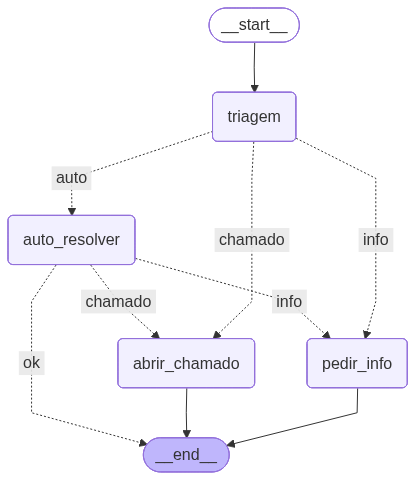

In [143]:
from IPython.display import display, Image

graph_bytes = grafo.get_graph().draw_mermaid_png()
display(Image(graph_bytes))

In [144]:
testes = [
    "Este é um exame médico. Com base na tomografia, qual é o nome do paciente?",
    "Este é um exame médico. Qual é a data registrada no exame de tomografia?",
    "Este é um exame médico. O exame de tomografia indica alguma alteração no fígado?",
    "Este é um exame médico. O que foi identificado na parede abdominal segundo o laudo da tomografia?",
    "Este é um exame médico. Quantos anos tem o paciente conforme consta no exame de tomografia?",
    "Este é um exame médico. Existe alguma recomendação médica registrada no relatório da tomografia?"
]



In [145]:
for msg_test in testes:
    resposta_final = grafo.invoke({
        "pergunta": msg_test,
        "documento": "TOMOGRAFIA ABDOME E PELVE.pdf",
        "forcar_no": "AUTO_RESOLVER"
    })

    print(f"PERGUNTA: {msg_test}")
    print(f"DECISÃO: {resposta_final.get('triagem', {}).get('decisao')} | URGÊNCIA: {resposta_final.get('triagem', {}).get('urgencia')} | AÇÃO FINAL: {resposta_final.get('acao_final')}")
    print(f"RESPOSTA: {resposta_final.get('resposta')}")

    if resposta_final.get("citacoes"):
        print("CITAÇÕES:")
        for citacao in resposta_final["citacoes"]:
            print(f" - Documento: {citacao['documento']}, Página: {citacao['pagina']}")
            print(f"   Trecho: {citacao['trecho']}")

    print("------------------------------------")


Executando nó de triagem...
Decidindo após a triagem...
Executando nó de auto_resolver...
Decidindo após o auto_resolver...
Rag com sucesso, finalizando o fluxo.
PERGUNTA: Este é um exame médico. Com base na tomografia, qual é o nome do paciente?
DECISÃO: AUTO_RESOLVER | URGÊNCIA: BAIXA | AÇÃO FINAL: AUTO_RESOLVER
RESPOSTA: O nome do paciente é ALESSANDRA CARDOZO DOS SANTOS.
CITAÇÕES:
 - Documento: TOMOGRAFIA ABDOME E PELVE.pdf, Página: 1
   Trecho: Paulo - SP - CEP:03014-000 - Tel: (11) 2799-3100 / www.hsv.org.br TOMOGRAFIA COMPUTADORIZADA DO ABDOME E PELVE Técnica: Exame realizado em aquisições multislice sem o uso do meio de contraste. Análise:
 - Documento: TOMOGRAFIA ABDOME E PELVE.pdf, Página: 2
   Trecho: clínico-laboratoriais além de outros exames de imagem prévios.
------------------------------------
Executando nó de triagem...
Decidindo após a triagem...
Executando nó de auto_resolver...
Decidindo após o auto_resolver...
Rag com sucesso, finalizando o fluxo.
PERGUNTA: Este é

A saída acima demonstra como, dada uma pergunta, o sistema primeiro busca as partes relevantes no seu documento PDF e, em seguida, usa essas partes para gerar uma resposta informada, citando as fontes originais. Isso é o cerne do Retrieval Augmented Generation (RAG)!